#Data Visualizations

This notebook contains exploratory and presentation-ready visualizations for B2 American Airlines to predict changes in flight arrival times and estimate the impact of these changes to inform time-sensitive airline operational decisions.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(
    "../data/raw/FlightInfo.csv",
    sep="|", #the separator is a pipe character
    engine="python" # Use the Python engine to handle the separator
                 )

Index(['|SEQ_NBR|SEQ_SCHD_START_DT|FLEET|BASE|DIVISION|SPOILAGE|TOTAL_BLOCKED_HRS|TOTAL_SPOILED_HRS|SEQ_CAL_DAYS|SEQ_DUTY_DAYS|SEQ_TTL_FLTTIME|MIN_FLYTIME_PER_LEG|MAX_LEGS_PER_DAY|SEQ_TTL_LEGS|MORETHAN2_321_LEGS|IN_SEQ_DHD|LAYOVER|SEQ_PATTERN|SEQ_START|FLIGHT_PATTERN|SEQ_START_HRS|SF_LOAD_TMS'], dtype='str')

# Choosing the Right Visualizations
mostly nums
 -> distributions, histograms, boxplots
categories labels
 -> bar charts, grouped summaries
dates
 -> time-series line plots

In [ ]:
df.columns.tolist()

['|SEQ_NBR|SEQ_SCHD_START_DT|FLEET|BASE|DIVISION|SPOILAGE|TOTAL_BLOCKED_HRS|TOTAL_SPOILED_HRS|SEQ_CAL_DAYS|SEQ_DUTY_DAYS|SEQ_TTL_FLTTIME|MIN_FLYTIME_PER_LEG|MAX_LEGS_PER_DAY|SEQ_TTL_LEGS|MORETHAN2_321_LEGS|IN_SEQ_DHD|LAYOVER|SEQ_PATTERN|SEQ_START|FLIGHT_PATTERN|SEQ_START_HRS|SF_LOAD_TMS']

# Spoilage vs No Spoliage
Our key outcome variable:
    spoilage(demad existed, seats flew empty)

# Key Questions
 How common is spoilage?
 Is it rare or frequent?

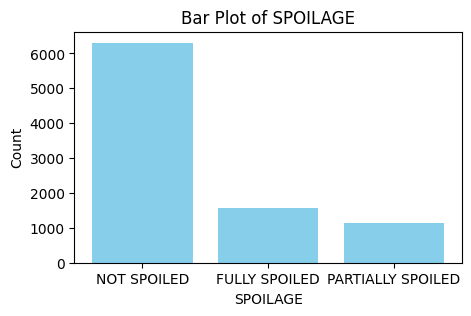

SPOILAGE
NOT SPOILED          6306
FULLY SPOILED        1570
PARTIALLY SPOILED    1149
Name: count, dtype: int64

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(
    "../data/raw/FlightInfo.csv",
    sep="|", #the separator is a pipe character
    engine="python" # Use the Python engine to handle the separator
                 )
df.head()
col = "SPOILAGE"

# counts
counts = df[col].value_counts()
counts

# Create a bar plot
plt.figure(figsize=(5, 3))
plt.bar(counts.index.astype(str), counts.values, color='skyblue')
plt.xlabel(col)
plt.ylabel('Count')
plt.title(f'Bar Plot of {col}')
plt.show()
counts

This visualization shows flights that are categorized as Fully Spoiled, Partially Spoiled, or Not Spoiled. As you can see, the amount of floghts not being spoiled is almost 3x more than fully and partially spoiled. We can leverage fully spoiled and partially spoiled to see how we can move things around to prevent spoilage.

# Total Spoiled Hrs (magnitude of waste)
 Is spoilage usually small or severe?
 Is distribution skewed?


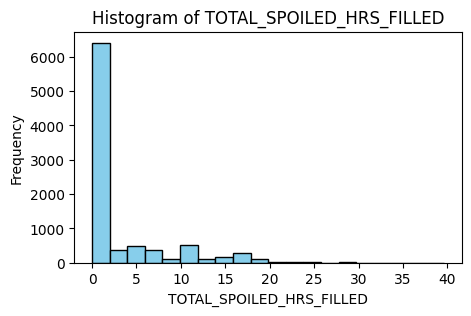

np.float64(0.30127423822714683)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(
    "../data/raw/FlightInfo.csv",
    sep="|", #the separator is a pipe character
    engine="python" # Use the Python engine to handle the separator
                 )
num_col = "TOTAL_SPOILED_HRS"

filled_col = "TOTAL_SPOILED_HRS_FILLED"
df[filled_col] = df[num_col].fillna(0)

df[filled_col].describe()
df[num_col].describe()

# Create a histogram
plt.figure(figsize=(5, 3))
plt.hist(df[filled_col], bins=20, color='skyblue', edgecolor='black')
plt.xlabel(filled_col)
plt.ylabel('Frequency')
plt.title(f'Histogram of {filled_col}')
plt.show()  
(df[filled_col] > 0).mean()

Approximately 70% of observations for Total Spoiled Hours are missing. Based on the bar plot above regarding the presence of spoilage and the operational context, spoliage events appear to be rare, Therefore, we interpret missing values as indicating no spoilage and recode them as zero hours. Under this assumption the distribution is highly right-skewed with the vast majority of flights experiencing zero or minimal spoilage and a small number exhbiting full spoilage.

Only 30% of flights experienced any spoilage.

# Sequence Complexity vs Spoliage 
 -Total Legs, Max Legs per day, Duty Days, Cal Days 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(
    "../data/raw/FlightInfo.csv",
    sep="|", #the separator is a pipe character
    engine="python" # Use the Python engine to handle the separator
                 )


count    9025.000000
mean        6.604647
std         7.885751
min         0.000000
25%         0.000000
50%         0.000000
75%        11.950000
max        39.660000
Name: TOTAL_BLOCKED_HRS_FILLED, dtype: float64


# Time of Day Effects
-start hours/time
-are sequences that start early or late more likely to spoil?

# Base & Division Differences 
# Deadhead & training constraints 
-Do operational constraints correlate wth spoilage?